In [1]:
import pandas as pd

In [8]:


df = pd.read_csv("retailsalesss.csv", encoding='latin1')

print(df.head())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156  08-11-2016  11-11-2016    Second Class    CG-12520   
1       2  CA-2016-152156  08-11-2016  11-11-2016    Second Class    CG-12520   
2       3  CA-2016-138688  12-06-2016  16-06-2016    Second Class    DV-13045   
3       4  US-2015-108966  11-10-2015  18-10-2015  Standard Class    SO-20335   
4       5  US-2015-108966  11-10-2015  18-10-2015  Standard Class    SO-20335   

     Segment        Country             City       State  ... Unnamed: 31  \
0   Consumer  United States        Henderson    Kentucky  ...         NaN   
1   Consumer  United States        Henderson    Kentucky  ...         NaN   
2  Corporate  United States      Los Angeles  California  ...         NaN   
3   Consumer  United States  Fort Lauderdale     Florida  ...         NaN   
4   Consumer  United States  Fort Lauderdale     Florida  ...         NaN   

  Unnamed: 32   Unnamed: 33 Unnamed: 34 Unnamed: 3

In [9]:
# Remove unwanted columns (Unnamed)
df = df.loc[:, ~df.columns.str.contains('Unnamed')]

# Remove junk rows (pivot table garbage)
df = df[df['Order ID'].notna()]

# Convert date columns
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True, errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True, errors='coerce')

# Convert numeric columns
df['Sales'] = pd.to_numeric(df['Sales'], errors='coerce')
df['Profit'] = pd.to_numeric(df['Profit'], errors='coerce')
df['Discount'] = pd.to_numeric(df['Discount'], errors='coerce')

# Drop nulls
df = df.dropna(subset=['Order Date','Sales'])

# Remove duplicates
df = df.drop_duplicates()

print("Cleaned Data Shape:", df.shape)

Cleaned Data Shape: (9994, 19)


In [11]:
#feature engineering
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['YearMonth'] = df['Order Date'].dt.to_period('M')
df['YearMonth'] = df['YearMonth'].astype(str)

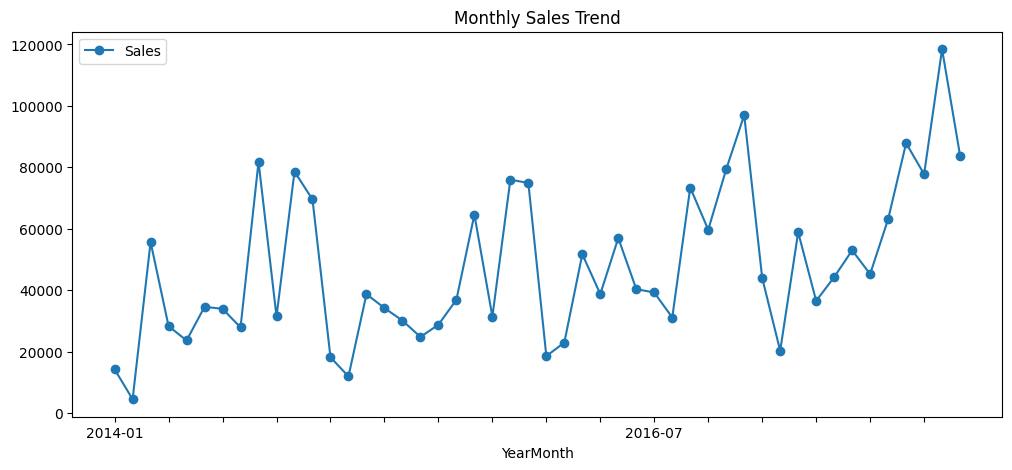

In [13]:
#MONTHLY SALES TREND (LINE GRAPH)
monthly_sales = df.groupby('YearMonth')['Sales'].sum().reset_index()

ax = monthly_sales.plot(
    x='YearMonth',
    y='Sales',
    kind='line',
    marker='o',
    figsize=(12,5),
    title='Monthly Sales Trend'
)

# Reduce clutter
ax.set_xticks(range(0, len(monthly_sales), 3))

<Axes: title={'center': 'Sales by Category'}, xlabel='Category'>

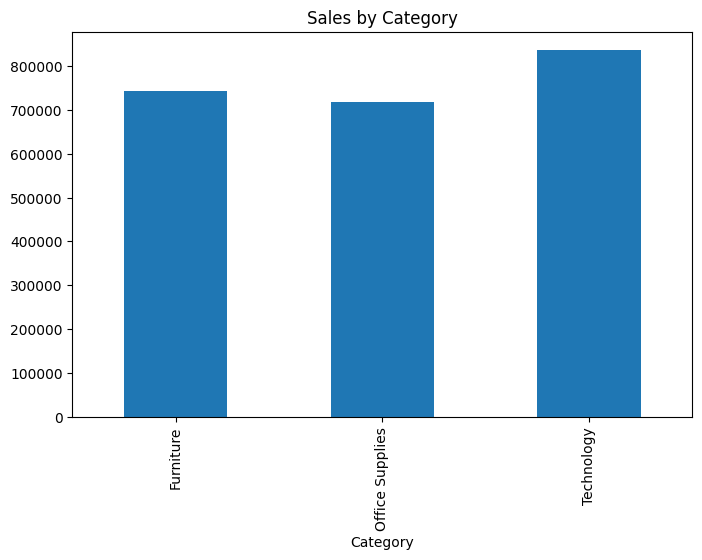

In [16]:
#SALES BY CATEGORY (BAR CHART)
category_sales = df.groupby('Category')['Sales'].sum()

category_sales.plot(
    kind='bar',
    figsize=(8,5),
    title='Sales by Category'
)

<Axes: title={'center': 'Sales by Region'}, xlabel='Region'>

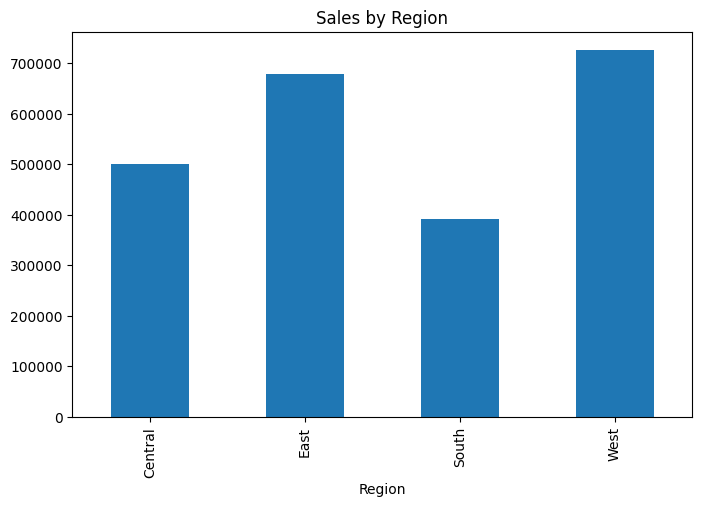

In [17]:
#SALES BY REGION (BAR CHART)
region_sales = df.groupby('Region')['Sales'].sum()

region_sales.plot(
    kind='bar',
    figsize=(8,5),
    title='Sales by Region'
)

<Axes: title={'center': 'Top 10 Products'}, xlabel='Product Name'>

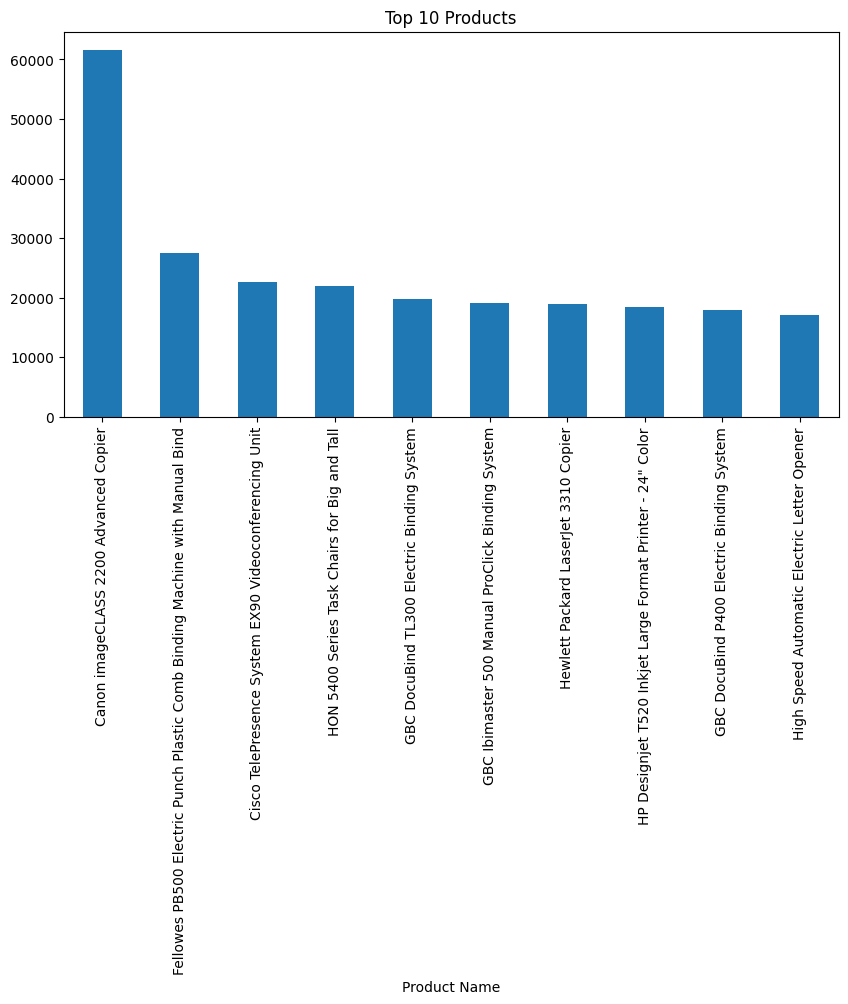

In [18]:
#TOP 10 PRODUCTS (BAR CHART)
top_products = df.groupby('Product Name')['Sales'].sum() \
                .sort_values(ascending=False).head(10)

top_products.plot(
    kind='bar',
    figsize=(10,5),
    title='Top 10 Products'
)

<Axes: title={'center': 'Sales vs Profit'}, xlabel='Sales', ylabel='Profit'>

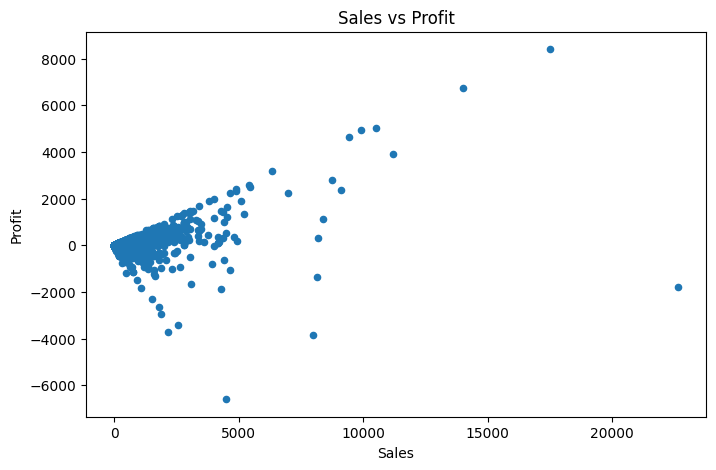

In [19]:
#SCATTER PLOT (Sales vs Profit)
df.plot(
    kind='scatter',
    x='Sales',
    y='Profit',
    figsize=(8,5),
    title='Sales vs Profit'
)

<Axes: title={'center': 'Discount vs Profit'}, xlabel='Discount', ylabel='Profit'>

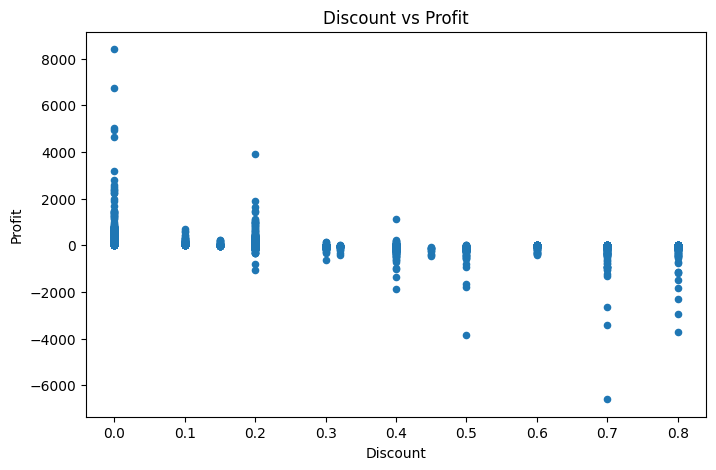

In [20]:
#SCATTER (Discount vs Profit)
df.plot(
    kind='scatter',
    x='Discount',
    y='Profit',
    figsize=(8,5),
    title='Discount vs Profit'
)

In [21]:
#KPI CALCULATIONS
total_sales = df['Sales'].sum()
total_orders = df['Order ID'].nunique()
avg_order_value = total_sales / total_orders

print("Total Sales:", total_sales)
print("Total Orders:", total_orders)
print("Average Order Value:", avg_order_value)

Total Sales: 2297201.0003
Total Orders: 5009
Average Order Value: 458.6146936114993


In [22]:
monthly_sales['Growth %'] = monthly_sales['Sales'].pct_change() * 100

print(monthly_sales.head())

  YearMonth      Sales     Growth %
0   2014-01  14236.895          NaN
1   2014-02   4519.892   -68.252263
2   2014-03  55691.009  1132.131409
3   2014-04  28295.345   -49.192257
4   2014-05  23648.287   -16.423401


In [23]:
df.to_csv("cleaned_superstore.csv", index=False)

In [24]:
pip install streamlit

   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   -------------------------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
Local URL: http://localhost:8501
  Network URL: http://10.139.41.234:8501